<a href="https://colab.research.google.com/github/drak247/MPA-MLF_230070_Havrda/blob/main/ex_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPA-MLF, Lab 6 - Feedforward Neural Networks with regularization techniques and hyperparameter tunning

## Exercise 1 - Classification of an images

The goal of this task will be to create Multi-layer perceptron model, that is able to recognize the  CIFAR10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html). The CIFAR10 dataset consist of 60000 images with resolution of 32x32 pixels. There are 10 classes in total - *airplane*, *automobile*, *bird*, *cat*, *deer*, *dog*, *frog*, *horse*, *ship*, *truck*

These is an example of the dataset:

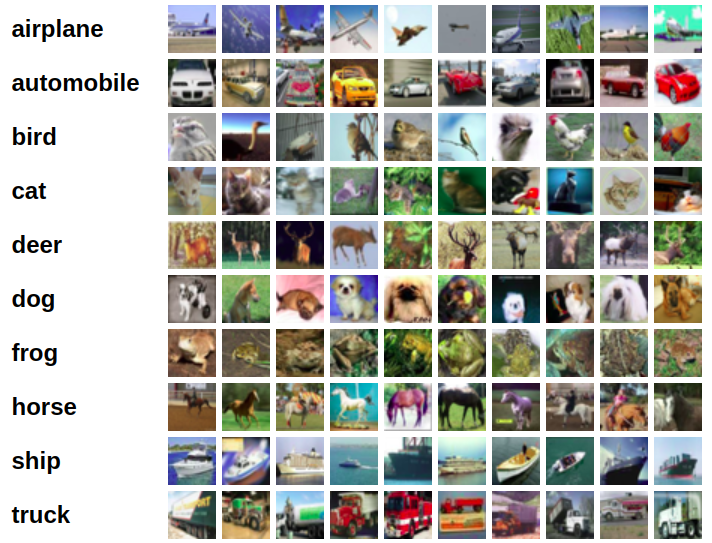

### 0. Import libraries

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import SGD
from keras.datasets import cifar10
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import cv2

font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Load the Dataset
The dataset is already a part of the Keras library, so we can quickly load it using the following command

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

The following numbered labels represent the labels in the dataset:

In [ ]:
labels = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

### 2. Data Examination

Fistly, lets have a look and the couple of images we have,

In [ ]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels_encoded = y_data[selected_ind]
  selected_labels = [labels[x[0]] for x in selected_labels_encoded]

  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img)

  for id_label, label in enumerate(selected_labels):
    plt.text((32/2) + 32*id_label - len(label), 32*(5/4), label)
  plt.axis('off')
  plt.show()



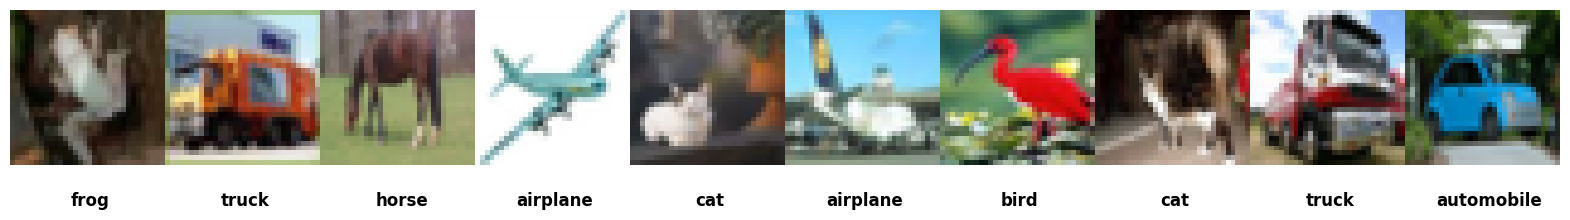

In [ ]:
display_random_images(X_train, y_train)

In [ ]:
#check the shape of image dataset

X_train.shape

(50000, 32, 32, 3)

In our dataset, we have 60000 images with 32x32 resolution. Each image has three channels (R, G, B). We have 50000 images for training and 10000 images for testing. Each channel for each image has values from 0 - 255, where each number represents the pixel intensity.
With the combination of intensities of R, G and B, you can display up to 16,777,216 different colours (256^3)

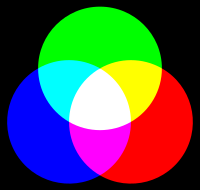

Here you can display each channel separately:

In [ ]:
def display_channels_separately(image: np.array) -> None:

  plt.figure()
  fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(10, 5))


  axs[0].imshow(image[:,:,0],cmap='Reds')
  axs[1].imshow(image[:,:,1],cmap='Blues')
  axs[2].imshow(image[:,:,2],cmap='Greens')

  axs[3].imshow(image)

  plt.show()

<Figure size 640x480 with 0 Axes>

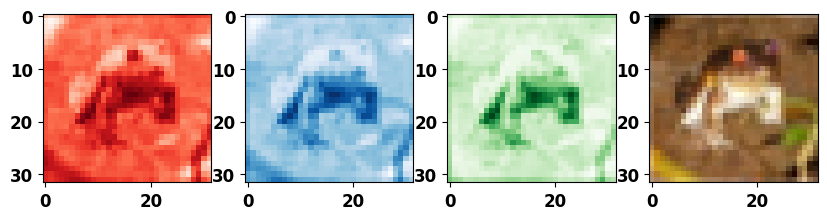

In [ ]:
display_channels_separately(X_train[0])

### 3. Preprocessing of the images

For machine learning purposes, we have to preprocess our images. Firstly we need to scale our images, to scale intensity values from 0-1 (min-max scaling)

In [ ]:
X_train_scaled = X_train.astype('float32') / 255.0

We need to one-hot-encode the labels in our ground truth variable as our second preprocessing.

In [ ]:
y_train_encoded = to_categorical(y_train, num_classes=10)

### 4. Define the model architecture

In [ ]:
model = Sequential()
model.add(Flatten(input_shape=(32, 32, 3)))
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))

We will define *the Sequential* model as in our last exercise. This time we will use a different approach to determine the input layers. Instead of specifying the *input_dim* parameter in our first hidden layer, we will create a **Flatten** layer that takes our 32x32x3 image and reshapes it into 1x3072.

We will specify ten neurons in our output layer because we have 10 possible outputs and a **softmax** activation function that returns us a probability distribution over the classes. The class with the highest probability is typically chosen as the predicted class for a given input.

Check the description of our model:

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

The next step is to compile our model, we will use *categorical_crossentropy* as a loss function, *stochastic gradient descend* as an optimisation and we will be checking *the accuracy* metric.

In [ ]:
optimizer = SGD(learning_rate = 0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

### 5. Train the model

Our model will be trained in the same way as in our last pc_labs,

In [ ]:
history = model.fit(X_train_scaled, y_train_encoded, epochs=20, batch_size=128, validation_split = 0.2)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1304 - loss: 2.2988 - val_accuracy: 0.1658 - val_loss: 2.2759
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1902 - loss: 2.2653 - val_accuracy: 0.2093 - val_loss: 2.2528
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2220 - loss: 2.2436 - val_accuracy: 0.2372 - val_loss: 2.2326
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2394 - loss: 2.2242 - val_accuracy: 0.2486 - val_loss: 2.2139
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2513 - loss: 2.2065 - val_accuracy: 0.2512 - val_loss: 2.1974
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2564 - loss: 2.1902 - val_accuracy: 0.2597 - val_loss: 2.1818
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2619 - loss: 2.1752 - val_accuracy: 0.2669 - val_loss: 2.1677
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2686 - loss: 2.1613 - val_accuracy: 0

### 6. Model evaluation

In [ ]:
X_test = X_test.astype('float32') / 255.0
y_test_encoded = to_categorical(y_test, num_classes=10)

In [ ]:
score = model.evaluate(X_test, y_test_encoded, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: {score[1]*100} %')

Test loss: 2.044658660888672
Test accuracy: 30.939999222755432 %


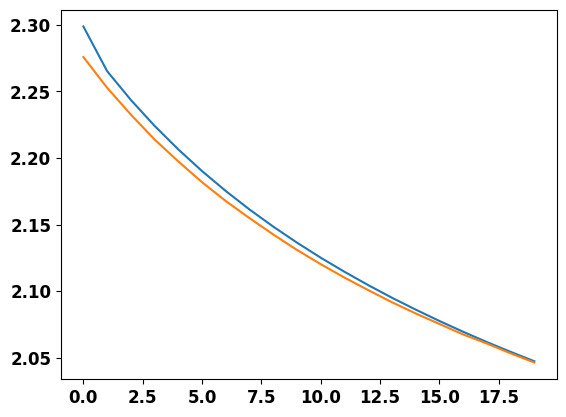

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

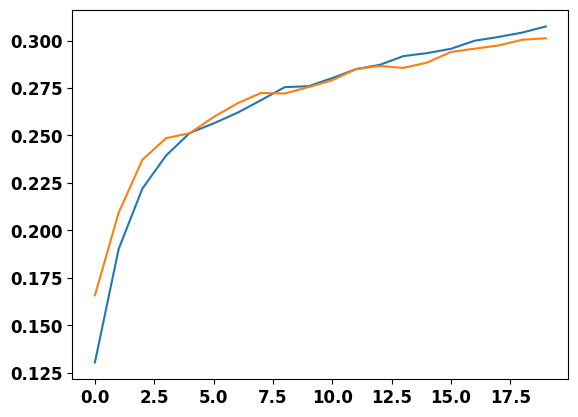

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

As you can see from the evaluation above, we was able to achive approx. 30% of an accuracy. In other word approx. 70% of an images we classified wrongly. That is really bad!

Lets check the best predictions from our model:

In [ ]:
def show_the_best_predictions(model, x_test: np.array, y_test: np.array, n_of_pred: int = 10) -> None:
  mapping = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

  predictions = model.predict(x_test)
  y_test = y_test.reshape(1,-1)
  predictions_ind = np.argmax(predictions, axis=1)
  predictions_ind = predictions_ind.reshape(1, -1)

  corect_predictions = np.where(predictions_ind == y_test)

  rows_correct = corect_predictions[1]
  predictedtions_correct = predictions[rows_correct]
  target_correct = y_test[0][rows_correct]

  max_samples = predictions[rows_correct, target_correct]
  selected_images = x_test[rows_correct]
  sorted_ind = np.argsort(max_samples)[::-1]


  images = []
  prob = []
  labels = []


  for ind in range(n_of_pred):

    index = sorted_ind[ind]

    labels.append(target_correct[index])
    prob.append(max_samples[index])
    images.append(selected_images[index])

  plt.figure(figsize=(20,10))

  images = np.concatenate(np.asarray(images),axis=1)
  plt.imshow(images)
  for ins in range(n_of_pred):
    texts = '{}: \n{:.3f} %'.format(mapping[labels[ins]], prob[ins]*100)
    plt.text((32/2) + 32*ins - len(mapping[labels[ins]]), 32*(5/4), texts)

  plt.axis('off')
  plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


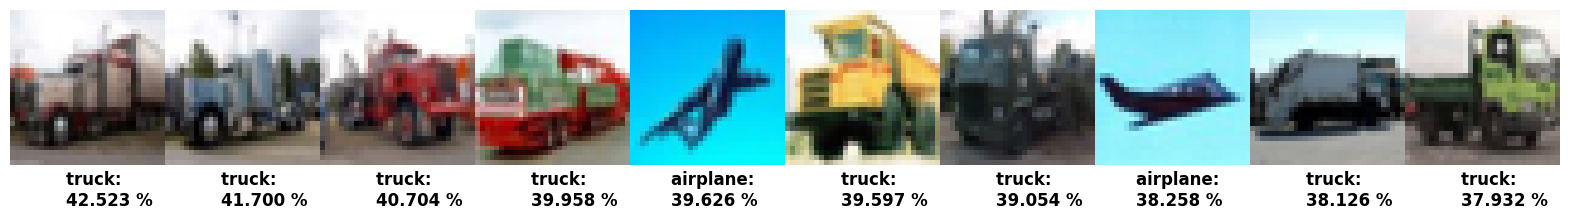

In [ ]:
show_the_best_predictions(model, X_test, y_test)

### Task Description:

You task of this exercise would be to improve the model's performance to achieve better results in image classification task. There is no need to change the preprocessing of the dataset. There are possible way how to improve the models performance:

1. Hyperparameter tunning - change the hyperparameters so that the model will perform better. You can experiment with the following:
 - *changing the number of neurons in the hidden layer*
 - *changing the number of hidden layers*
 - *changing the activation functions*
 - *changing the learning rate*
 - *changing the optimizer* - So far, we have used only Gradient descend as our optimizer, but Keras offers other algorithms that can perform better - check the documentation!
 - *changing the number of learning epochs*\
 - *changing the batch size*

2. Regularization techniques - There are several regularization techniques that can improve the model's performance:
 - *Dropout* -  In the Keras lib. you can add *dropout layer* into your Sequential model using the following command  *model.add(Dropout(p))* where *p* is an hyperparameter that controls dropout probabily, typical values are 0.1 - 0.5.
 - *L1, L2 regularization* - In keras the regularization is applied for selected layers, there is an example how to add l2 regularization to an layer (for more details check the documnetation):  *model.add(Dense(64, activation='relu', input_dim=100, kernel_regularizer=l2(0.01)))*
 - *Early stopping* -  In Keras, you can use the EarlyStopping callback to implement early stopping in your model. *early_stopping = EarlyStopping(monitor='val_loss', patience=3)*,  *model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])*


Try to make the highest testing accuracy possible. You can directly edit the code that is presented above, or you can copy everything into new cells. Please submit only the code with the best performance and briefly describe what approaches you have tried and what were the results

### WRITE YOUR DESCRIPTION IN THIS CELL ###
Used:
- leakyReLU as function
- SGD optimiser
- batch size 64
- learning rate 0.01
got outputs
Leaky ReLU Model Test loss: 1.5785548686981201
Leaky ReLU Model Test accuracy: 52.34000086784363 %

### Voluntary task:
Implement one of the hyperparameter tunning algorithms discussed in the lecture, such as *Grid Search*, *Random Search* or more sophisticated ones. Some of these algorithms are already included in the Keras. Check the documentation

In [ ]:
from keras.layers import LeakyReLU
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.optimizers import SGD
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from keras.datasets import cifar10
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# Define the improved model architecture with Leaky ReLU
model_leaky_relu = Sequential()
model_leaky_relu.add(Flatten(input_shape=(32, 32, 3)))
model_leaky_relu.add(Dense(256, kernel_regularizer=l2(0.001)))
model_leaky_relu.add(LeakyReLU(alpha=0.1)) # Leaky ReLU activation
model_leaky_relu.add(Dropout(0.3))
model_leaky_relu.add(Dense(128, kernel_regularizer=l2(0.001)))
model_leaky_relu.add(LeakyReLU(alpha=0.1)) # Leaky ReLU activation
model_leaky_relu.add(Dropout(0.3))
model_leaky_relu.add(Dense(10, activation='softmax'))

# Compile the improved model
optimizer_adam_leaky_relu = SGD(learning_rate=0.01)
model_leaky_relu.compile(loss='categorical_crossentropy', optimizer=optimizer_adam_leaky_relu, metrics=['accuracy'])

# Define Early Stopping callback
early_stopping_leaky_relu = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the improved model
history_leaky_relu = model_leaky_relu.fit(X_train_scaled, y_train_encoded, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping_leaky_relu])



Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2353 - loss: 2.7192 - val_accuracy: 0.3197 - val_loss: 2.5486
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3062 - loss: 2.5404 - val_accuracy: 0.3506 - val_loss: 2.4617
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3362 - loss: 2.4603 - val_accuracy: 0.3753 - val_loss: 2.3840
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3564 - loss: 2.3979 - val_accuracy: 0.3928 - val_loss: 2.3221
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3670 - loss: 2.3523 - val_accuracy: 0.3936 - val_loss: 2.2949
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3819 - loss: 2.3080 - val_accuracy: 0.4053 - val_loss: 2.2506
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3934 - loss: 2.2722 - val_accuracy: 0.4215 - val_loss: 2.2098
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3985 - loss: 2.2383 - val_accu

In [ ]:
model_leaky_relu.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_32 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_33 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,876 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Leaky ReLU Model Test loss: 1.5785548686981201
Leaky ReLU Model Test accuracy: 52.34000086784363 %


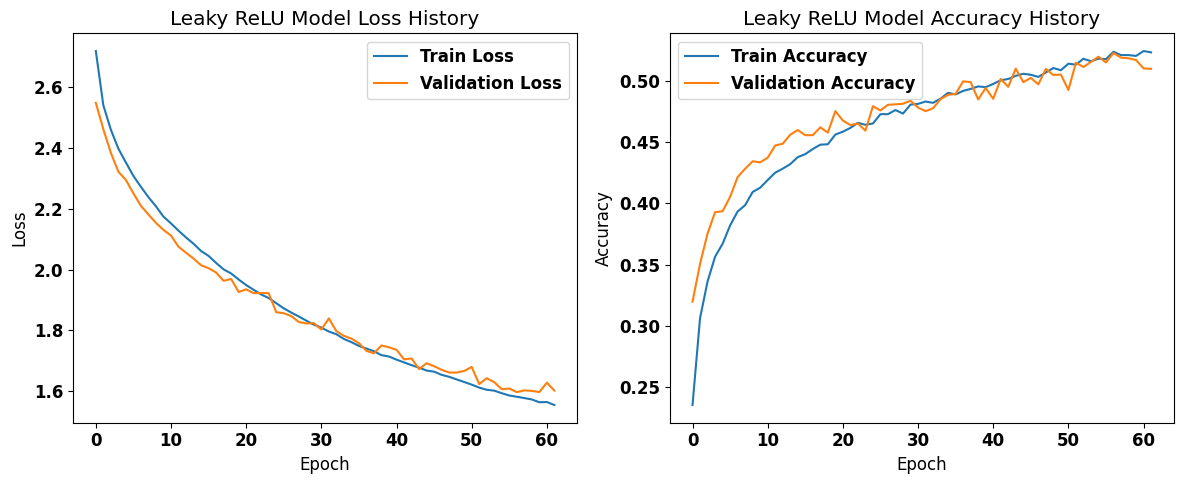

In [ ]:
# Evaluate the improved model
score_leaky_relu = model_leaky_relu.evaluate(X_test, y_test_encoded, verbose=0)
print('Leaky ReLU Model Test loss:', score_leaky_relu[0])
print(f'Leaky ReLU Model Test accuracy: {score_leaky_relu[1]*100} %')

# Plotting training history for improved model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_leaky_relu.history['loss'], label='Train Loss')
plt.plot(history_leaky_relu.history['val_loss'], label='Validation Loss')
plt.title('Leaky ReLU Model Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_leaky_relu.history['accuracy'], label='Train Accuracy')
plt.plot(history_leaky_relu.history['val_accuracy'], label='Validation Accuracy')
plt.title('Leaky ReLU Model Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


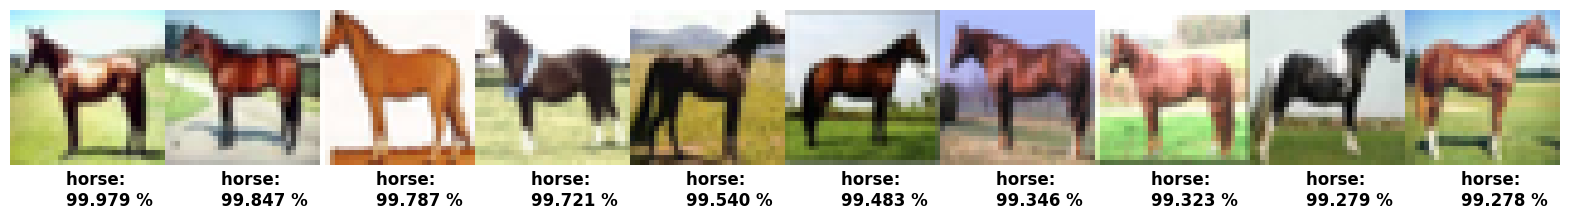

In [ ]:
show_the_best_predictions(model_leaky_relu, X_test, y_test)

In [ ]:
(X_train2, y_train2), (X_test2, y_test2) = cifar10.load_data()
labels2 = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

# **I wanted to try using convolution layers because we are working with images.**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.regularizers import l2

weight_decay = 1e-4

modelcv = Sequential()

# 🔹 Block 1
modelcv.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(weight_decay), input_shape=(32,32,3)))
modelcv.add(BatchNormalization())
modelcv.add(LeakyReLU(alpha=0.1))

modelcv.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(weight_decay)))
modelcv.add(BatchNormalization())
modelcv.add(LeakyReLU(alpha=0.1))

modelcv.add(MaxPooling2D((2,2)))
modelcv.add(Dropout(0.25))


# 🔹 Block 2
modelcv.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(weight_decay)))
modelcv.add(BatchNormalization())
modelcv.add(LeakyReLU(alpha=0.1))

modelcv.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(weight_decay)))
modelcv.add(BatchNormalization())
modelcv.add(LeakyReLU(alpha=0.1))

modelcv.add(MaxPooling2D((2,2)))
modelcv.add(Dropout(0.3))


# 🔹 Block 3
modelcv.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(weight_decay)))
modelcv.add(BatchNormalization())
modelcv.add(LeakyReLU(alpha=0.1))

modelcv.add(MaxPooling2D((2,2)))
modelcv.add(Dropout(0.4))


# 🔹 Classifier
modelcv.add(Flatten())

modelcv.add(Dense(128, kernel_regularizer=l2(weight_decay)))
modelcv.add(BatchNormalization())
modelcv.add(LeakyReLU(alpha=0.1))
modelcv.add(Dropout(0.5))

modelcv.add(Dense(10, activation='softmax'))

In [ ]:
from keras.layers import LeakyReLU
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from keras.optimizers import SGD
from keras.regularizers import l2
from keras.callbacks import EarlyStopping
from keras.datasets import cifar10
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

modelcv = Sequential()

modelcv.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(weight_decay), input_shape=(32,32,3)))
modelcv.add(BatchNormalization())
modelcv.add(LeakyReLU(alpha=0.1))

modelcv.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(weight_decay)))
modelcv.add(BatchNormalization())
modelcv.add(LeakyReLU(alpha=0.1))

modelcv.add(MaxPooling2D((2,2)))
modelcv.add(Dropout(0.25))

# Define the improved model architecture with Leaky ReLU

modelcv.add(Flatten())
modelcv.add(Dense(256, kernel_regularizer=l2(0.001)))
modelcv.add(LeakyReLU(alpha=0.1)) # Leaky ReLU activation
modelcv.add(Dropout(0.3))
modelcv.add(Dense(128, kernel_regularizer=l2(0.001)))
modelcv.add(LeakyReLU(alpha=0.1)) # Leaky ReLU activation
modelcv.add(Dropout(0.3))
modelcv.add(Dense(10, activation='softmax'))

# Compile the improved model
optimizer_adam_leaky_relu = SGD(learning_rate=0.005)
modelcv.compile(loss='categorical_crossentropy', optimizer=optimizer_adam_leaky_relu, metrics=['accuracy'])

# Define Early Stopping callback
early_stopping_leaky_relu = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the improved model
history_leaky_relu = modelcv.fit(X_train_scaled, y_train_encoded, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stopping_leaky_relu])


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.2549 - loss: 2.7250 - val_accuracy: 0.2621 - val_loss: 2.7075
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3521 - loss: 2.4490 - val_accuracy: 0.4131 - val_loss: 2.3270
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3943 - loss: 2.3196 - val_accuracy: 0.4540 - val_loss: 2.2067
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4300 - loss: 2.2262 - val_accuracy: 0.4904 - val_loss: 2.1021
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4521 - loss: 2.1589 - val_accuracy: 0.5107 - val_loss: 2.0340
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4723 - loss: 2.1019 - val_accuracy: 0.5331 - val_loss: 1.9824
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4868 - loss: 2.0527 - val_accuracy: 0.5448 - val_loss: 1.9469
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5049 - loss: 2.0081 - val_

Leaky ReLU Model Test loss: 1.596436858177185
Leaky ReLU Model Test accuracy: 64.24999833106995 %


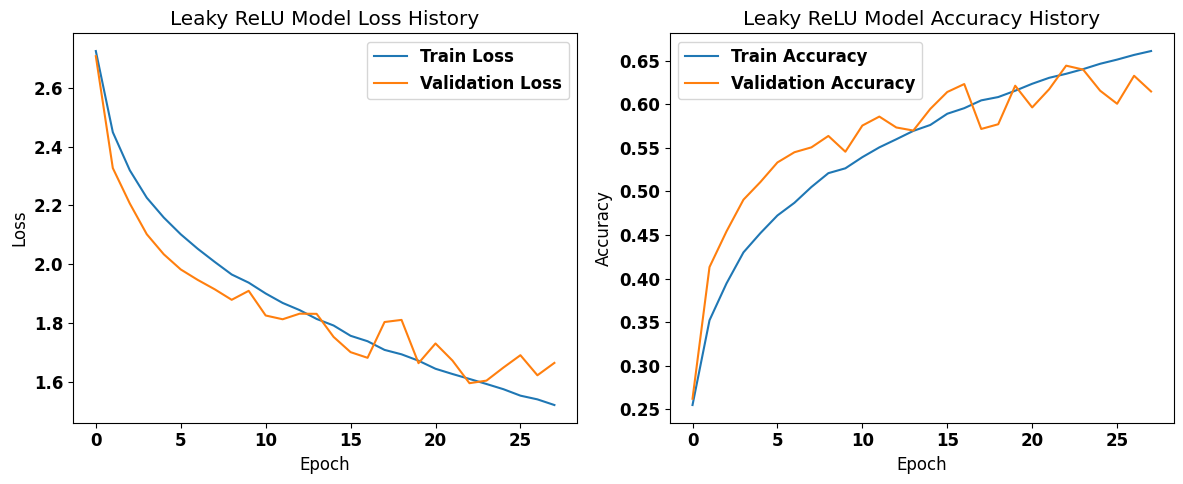

In [ ]:
# Evaluate the improved model
score_leaky_relu = modelcv.evaluate(X_test, y_test_encoded, verbose=0)
print('Leaky ReLU Model Test loss:', score_leaky_relu[0])
print(f'Leaky ReLU Model Test accuracy: {score_leaky_relu[1]*100} %')

# Plotting training history for improved model
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_leaky_relu.history['loss'], label='Train Loss')
plt.plot(history_leaky_relu.history['val_loss'], label='Validation Loss')
plt.title('Leaky ReLU Model Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_leaky_relu.history['accuracy'], label='Train Accuracy')
plt.plot(history_leaky_relu.history['val_accuracy'], label='Validation Accuracy')
plt.title('Leaky ReLU Model Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


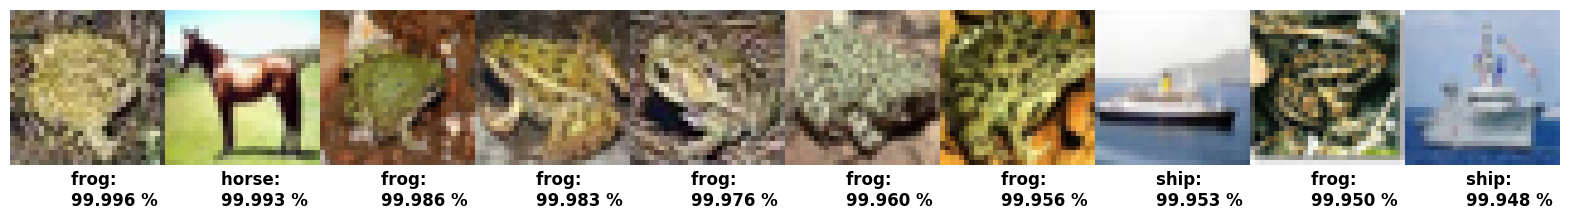

In [ ]:
show_the_best_predictions(modelcv, X_test, y_test)